# 03 — Interp bridge: residual stream ↔ self-reports

**Intent.** First rung of the interp ladder: do the five self-report axes
exist as linearly decodable directions in the residual stream, at which
layers — and when in the conversation does the *final outcome* become
readable from a single turn's activations?

**Claims reviewed here**

- **C5** — per (layer, axis): group-CV correlation of a ridge probe decoding
  each self-report from the same turn's residual, vs a trial-level shuffled
  control.
- **C6** — per (layer, turn): accuracy of predicting the trial's final
  gave_in from that single turn's residual — "when is the die cast".

Code under review: `production/driftlab/interp.py`, `datasets.load_cache`.

**Not claimed here:** anything causal, and anything about *which parts of the
input attended* to these axes — the current cache stores only the last-token
residual per assistant turn. Attention attribution needs a richer replay
cache; that is queued as the next microscope extension.

## Methods

**Cache.** `replay_cache.py` re-runs each logged conversation through the
local model and stores the residual at the last content token of every
assistant turn: `resid[trial, turn, layer, d]`. Turn *t* (0-based) is the
reply of round *t+1*; the extra final turn is the answer the give-in marker
reads. Alignment is asserted at load (`dims` is `[trial, R, 5]`).

**Probe.** Ridge regression in the dual (n ≪ d), 5-fold CV where **folds
never split a trial** — turns of one conversation are correlated, so the
trial is the unit of evidence. Reported number: Pearson r between held-out
predictions and truth.

**Control.** Labels shuffled at the *trial* level and pushed through the
identical pipeline, so the control keeps the within-trial correlation
structure the real probe must beat. Signal is the gap between the two
heatmaps, not any raw number.

**Label caveat.** Cache sidecar labels are run-time labels; the behavioral
tables in notebook 01 re-derive outcomes with current markers. The cell
below cross-checks the two sources before anything is probed.

In [1]:
# bootstrap: notebooks review code that lives in production/ — nothing is
# defined here that a claim rests on.
import sys, os
sys.path.insert(0, os.path.abspath('../production'))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from driftlab import load_cache, load_turns
from driftlab.interp import dim_layer_map, gavein_turn_probe
from driftlab.datasets import DIMS

cache = load_cache('qwen3.5-9b')
n, T, L, d = cache['resid'].shape
print(f"resid  [trial={n}, turn={T}, layer={L}, d={d}]  "
      f"{cache['resid'].nbytes/1e6:.0f} MB as float32")
print(f"dims   {cache['dims'].shape}   NaN (unparsed): "
      f"{np.isnan(cache['dims']).any(axis=2).sum()} trial-rounds")
print(f"gave_in balance: {cache['gave_in'].mean():.2f}")

resid  [trial=72, turn=9, layer=33, d=4096]  350 MB as float32
dims   (72, 8, 5)   NaN (unparsed): 0 trial-rounds
gave_in balance: 0.50


In [2]:
# consistency check: run-time cache labels vs marker-rescored behavioral labels
beh = load_turns('qwen3.5-9b').drop_duplicates('trial')
cachemeta = pd.DataFrame({'agent': cache['agent'], 'gave_in': cache['gave_in']})
check = pd.DataFrame({
    'cache (run-time)': cachemeta.groupby('agent').gave_in.sum().astype(int),
    'behavioral (rescored)': beh.groupby('agent').gave_in.sum().astype(int),
    'n': cachemeta.groupby('agent').size()})
check

note: 1 trial outcome(s) re-derived from the stored replies — the markers have been corrected since those ran


,cache (run-time),behavioral (rescored),n
agent,,,
convincer,20,20,24
neutral,11,11,24
supportive,5,5,24


In [3]:
!cd ../production && ../.venv/bin/python -m pytest tests/test_interp.py -q

..

.

..                                                                    [100%]
5 passed in 0.28s


## Results — C5: which layers carry which self-report axis (qwen3.5-9b)

In [4]:
import time
t0 = time.time()
r9, r9_sh = dim_layer_map(cache)
print(f"{time.time()-t0:.0f}s")

53s


best cell: layer 22, strategy, r=0.486 (control there: 0.191)


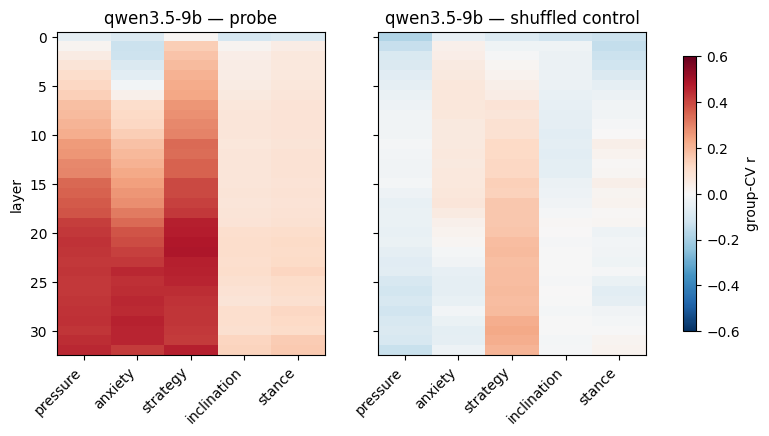

In [5]:
def dim_heat(r, r_sh, model):
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), sharey=True)
    for ax, mat, name in ((axes[0], r, 'probe'), (axes[1], r_sh, 'shuffled control')):
        im = ax.imshow(mat, aspect='auto', vmin=-0.6, vmax=0.6, cmap='RdBu_r')
        ax.set_xticks(range(5), DIMS, rotation=45, ha='right')
        ax.set_title(f'{model} — {name}')
    axes[0].set_ylabel('layer')
    fig.colorbar(im, ax=axes, label='group-CV r', shrink=0.85)
    best = np.unravel_index(np.nanargmax(r), r.shape)
    print(f"best cell: layer {best[0]}, {DIMS[best[1]]}, r={r[best]:.3f} "
          f"(control there: {r_sh[best]:.3f})")

dim_heat(r9, r9_sh, 'qwen3.5-9b')

## Results — C6: when does the outcome become readable (qwen3.5-9b)

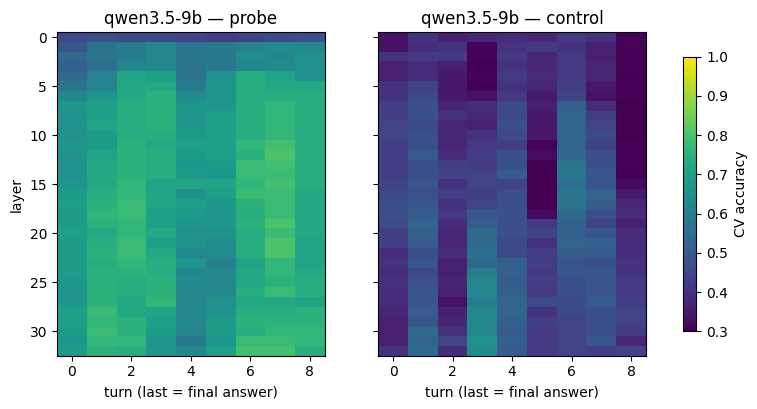

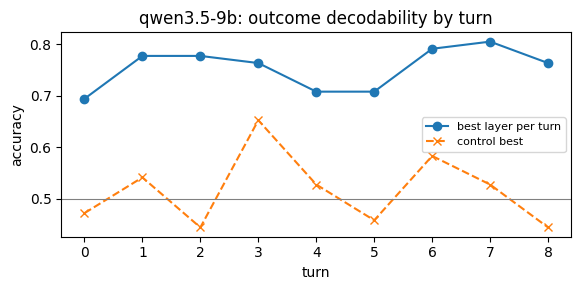

In [6]:
acc9, acc9_sh = gavein_turn_probe(cache)
def turn_heat(acc, acc_sh, model):
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), sharey=True)
    for ax, mat, name in ((axes[0], acc, 'probe'), (axes[1], acc_sh, 'control')):
        im = ax.imshow(mat, aspect='auto', vmin=0.3, vmax=1.0, cmap='viridis')
        ax.set_xlabel('turn (last = final answer)'); ax.set_title(f'{model} — {name}')
    axes[0].set_ylabel('layer')
    fig.colorbar(im, ax=axes, label='CV accuracy', shrink=0.85)
    fig2, ax2 = plt.subplots(figsize=(6, 3))
    ax2.plot(acc.max(axis=0), marker='o', label='best layer per turn')
    ax2.plot(acc_sh.max(axis=0), marker='x', ls='--', label='control best')
    ax2.axhline(0.5, color='gray', lw=0.8)
    ax2.set_xlabel('turn'); ax2.set_ylabel('accuracy'); ax2.legend(fontsize=8)
    ax2.set_title(f'{model}: outcome decodability by turn')
    plt.tight_layout()

turn_heat(acc9, acc9_sh, 'qwen3.5-9b')

## Cross-model check: ministral-3-14b, same pipeline, no retuning

resid (72, 9, 41, 5120) gave_in balance 0.67


best cell: layer 34, inclination, r=0.776 (control there: 0.193)


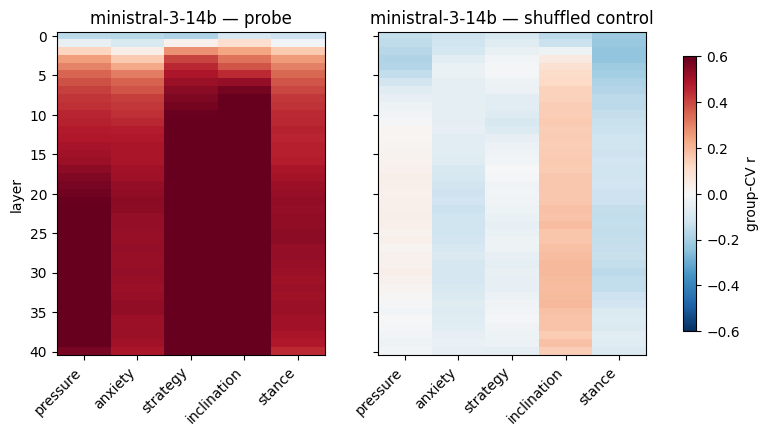

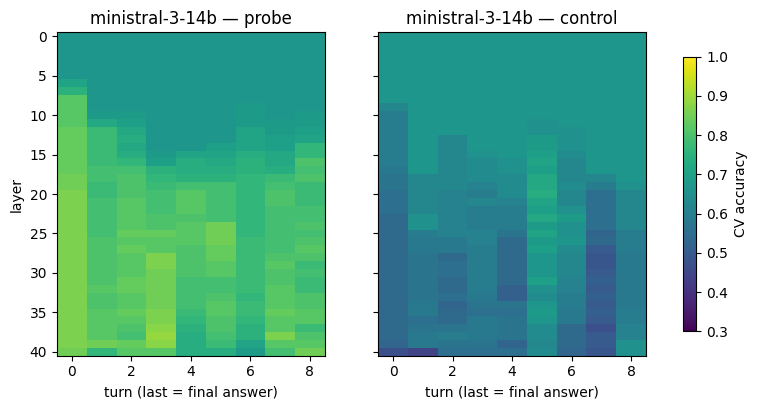

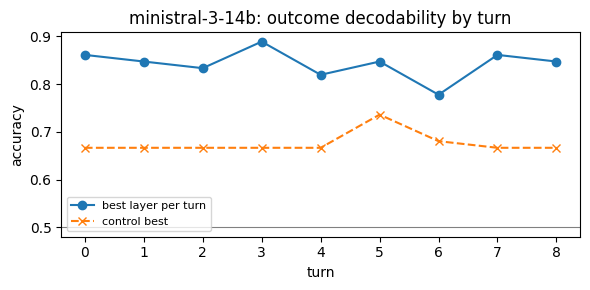

In [7]:
cachem = load_cache('ministral-3-14b')
print('resid', cachem['resid'].shape, 'gave_in balance',
      round(float(cachem['gave_in'].mean()), 2))
rm, rm_sh = dim_layer_map(cachem)
dim_heat(rm, rm_sh, 'ministral-3-14b')
accm, accm_sh = gavein_turn_probe(cachem)
turn_heat(accm, accm_sh, 'ministral-3-14b')

## Discussion

How to read these, and what each pattern would mean:

- **C5.** An axis is "present" in the residual stream only where the probe
  heatmap clearly exceeds its shuffled twin across a band of layers — a
  single hot cell at one layer is fold noise until it replicates. If
  `strategy` (the load-bearing behavioral axis from notebook 02) is among
  the most decodable, the self-reports and the activations are telling one
  story; if the *reported* axes decode poorly while gave_in decodes well
  (C6), the model's verbal self-account and its internal state have come
  apart — arguably the more publishable outcome.
- **C6.** The per-turn curve is the interp twin of notebook 02's divergence
  question: accuracy rising above control *before* the final turn means the
  outcome is encoded before it is enacted. Last night's pooled probe
  (L24, 0.760 vs 0.500 control) says moderate decodability exists; this
  notebook localizes it in time.
- **Confound, again:** agent predicts gave_in, so part of any outcome probe
  may be an *agent* probe. The within-condition version (convincer-only,
  n=24) is the follow-up once more trials bank — noted, not yet run.
- **Next rungs:** (1) per-axis directions compared across layers
  (cos alignment, as in microscope L2); (2) attention attribution to locate
  *what the model was reading* when these directions move — requires
  extending replay_cache beyond last-token residuals.